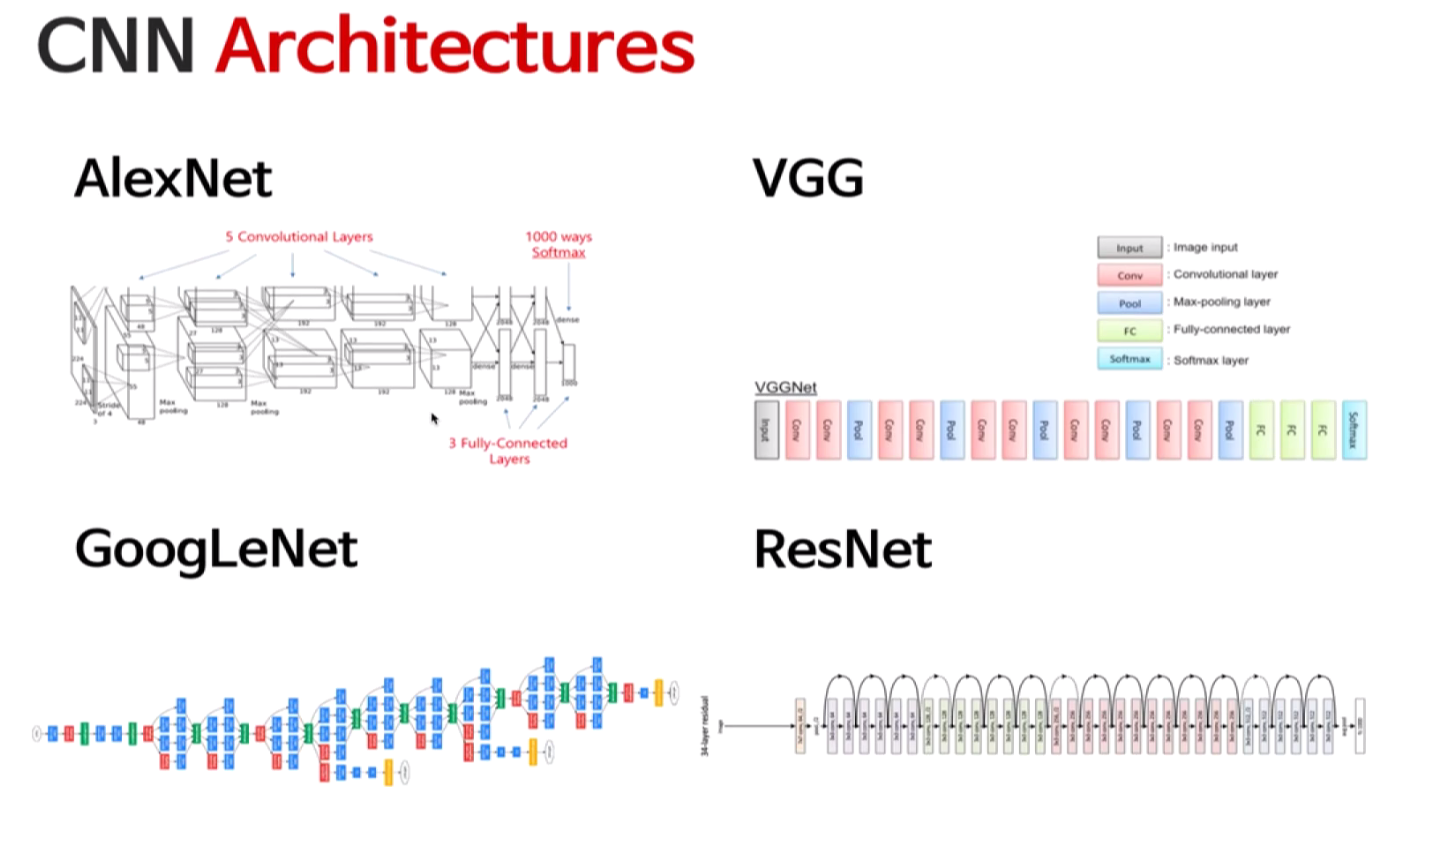

* Transfer Learning methods developed by universities (AlexNet from University of Toronto; ) and big companies like Google (GoogLeNet), Facebook (ResNet), Microsoft (Turing-NLG for NLP). 


* The process of **adjusting our data** according **to** our chosen **transfer learning model** is called **Fine Tuning**.

In [1]:
# Keras web page:  https://keras.io/api/applications/

In [2]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Hide all warnings
import warnings
warnings.filterwarnings("ignore")

# Hide deprecated warnings in Keras and TensorFlow
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [3]:
os.getcwd()

'C:\\Users\\jawed\\Desktop\\B287 DL\\04 CNN\\Repo Notebooks\\06 Transfer Learning Cats & Dogs'

The Dogs vs. Cats dataset is a common computer vision dataset in which pictures are classified as either including a dog or a cat.

After the dataset is well studied, it can be used to understand and practice how to design, evaluate, and apply convolutional neural networks for image classification.

You will build a classifier with images and try to detect dogs versus cats using CNN.

Train set includes 12500 cat-5026 dog images, validation set includes 1219 cat-1071 dog images and test set incgludes 6897 cat and dogs images together. 

In [4]:
my_data_dir='datam/'

In [5]:
os.listdir(my_data_dir)

['test', 'train']

In [6]:
train_path = my_data_dir+'train'
test_path = my_data_dir+'test'

In [7]:
os.listdir(train_path)

['cat', 'dog']

**Let's check how many images there are.**

In [8]:
len(os.listdir(train_path+'/cat'))

12500

In [9]:
len(os.listdir(train_path+'/dog'))

5026

In [10]:
os.listdir(train_path+'/cat')[0]

'cat.0.jpg'

In [11]:
path1=train_path+'/cat'+'/cat.1000.jpg'
path2=train_path+'/dog'+'/dog.1000.jpg'

In [12]:
cat_img=imread(path1)
dog_img=imread(path2)

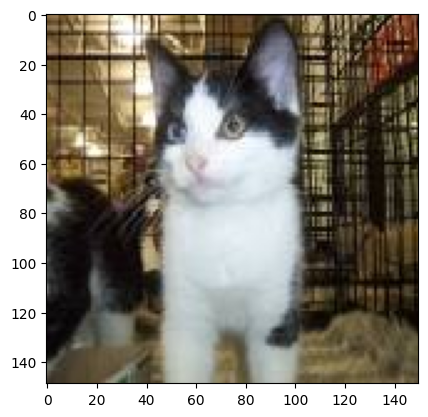

In [13]:
plt.imshow(cat_img);

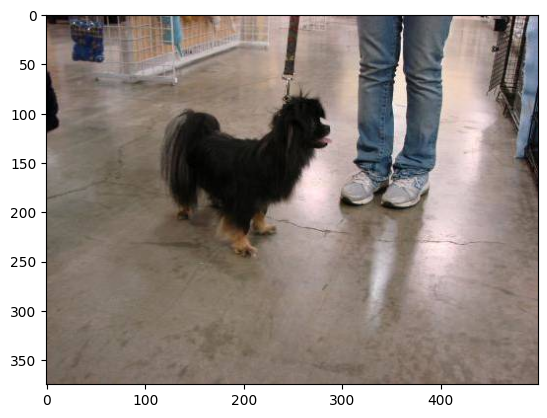

In [14]:
plt.imshow(dog_img);

**Let's decide on the final dimension of these images.**

In [15]:
cat_img.max()

np.uint8(255)

In [16]:
cat_img.min()

np.uint8(0)

In [17]:
cat_img.shape

(149, 150, 3)

In [18]:
dog_img.shape

(375, 499, 3)

In [19]:
x= []
y = []
for image in os.listdir(train_path+'/cat'):
    
    img = imread(train_path+'/cat/'+image)
    d1,d2,colors = img.shape
    x.append(d1)
    y.append(d2)

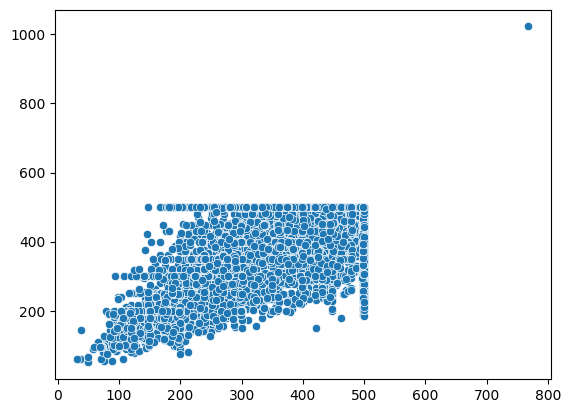

In [20]:
sns.scatterplot(x=x,y=y);

In [21]:

np.mean(x)

np.float64(356.46712)

In [22]:
np.mean(y)

np.float64(410.52264)

In [23]:
image_shape = (224, 224,3) # Since VGG16 trained on (224, 224, 3) images. https://keras.io/api/applications/vgg/#vgg16-function

In [24]:
# help(ImageDataGenerator)

**Image Manipulation**

We can use the ImageDataGenerator to manipulate the images with rotation, resizing, and scaling so the model becomes more robust to different images that our data set doesn't have. ImageDataGenerator does the followings.

* Accepts a batch of images used for training.
* Applies a series of random transformations to each image in the batch.
* Replaces the original batch with randomly transformed batch.
* Training the CNN on this randomly transformed batch.

The goal of applying data augmentation is to have a more generalized model.

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input # For preprocessing (rescaling)

In [26]:
image_gen = ImageDataGenerator(rotation_range=20, # rotate the image 20 degrees
                               width_shift_range=0.10, # Shift the pic width by a max of 10%
                               height_shift_range=0.10, # Shift the pic height by a max of 10%
                               
                               #rescale=1/255, # Rescale the image by normalzing it.DON't DO IT
                               
                               # preprocessing_function=preprocess_input,  # I gave it in model architechture 
                               
                               shear_range=0.1, # Shear means cutting away part of the image (max 10%)
                               zoom_range=0.1, # Zoom in by 10% max
                               horizontal_flip=True, # Allo horizontal flipping
                               fill_mode='nearest' # Fill in missing pixels with the nearest filled value
                              )

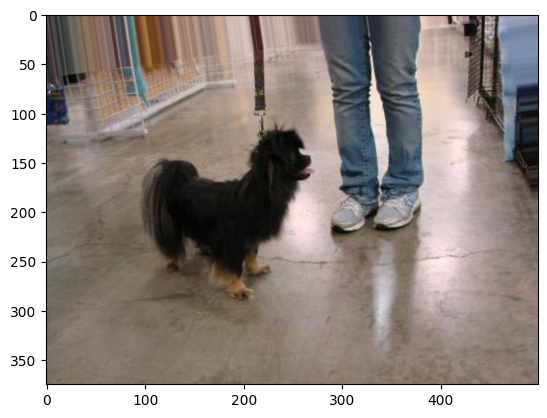

In [27]:
plt.imshow(image_gen.random_transform(dog_img));

image_gen.flow_from_directory(train_path)

# Creating the Model

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input  # for preprocessing

In transfer learning models; 

1) **include_top=False** --> We are setting up the ANN part.

2) **weights= "imagenet"** --> Use the weights learned while training on imageNet data.

3) **layer.trainable=False** --> The model doesn't trained from scratch, the weights it has previously learned should be used.

# I got an error but it should work on your computer... 

The error you're encountering is due to an issue with the download of the imagenet weights for the EfficientNetV2S model, where the file may be incomplete or corrupted. Here are steps to resolve it:

Delete Cached File and Re-download: To trigger a fresh download, you may need to delete the corrupted weight file from the cache. You can do this with the following code:

from keras.utils import get_file
import os

**Path to the EfficientNetV2S weights file**

weight_path = get_file(
    "efficientnetv2-s_notop.h5",
    origin="https://storage.googleapis.com/keras-applications/efficientnetv2/efficientnetv2-s_notop.h5",
    cache_subdir="models"
)

**Remove the file if it exists**

if os.path.exists(weight_path):
    os.remove(weight_path)


Restart the Download Process: Rerun your code to initiate a new download of the imagenet weights for the EfficientNetV2S model.

Manual Download (Optional): If the issue persists, you can manually download the EfficientNetV2S weights and place the file in the models folder of your cache directory.

In [29]:
# Call EfficientNetV2S 
EfficientNetV2S_model = Sequential()

pretrained_model = EfficientNetV2S(include_top=False,
                                    input_shape=(224, 224, 3),
                                    weights='imagenet',
                                    pooling=None,
                                   classifier_activation="softmax", 
                                   include_preprocessing=True) # !!! preprocessing here

# Use EfficientNetV2S weights
for layer in pretrained_model.layers:
    layer.trainable = False

EfficientNetV2S_model.add(pretrained_model)

# Flatten Layer (Input)
EfficientNetV2S_model.add(Flatten())

# ---ANN---

# Fully Connected Layer
EfficientNetV2S_model.add(Dense(512, activation='relu'))
EfficientNetV2S_model.add(BatchNormalization())
EfficientNetV2S_model.add(Dropout(0.3))

EfficientNetV2S_model.add(Dense(64, activation='relu'))
EfficientNetV2S_model.add(Dense(1, activation='sigmoid')) # binary classification
EfficientNetV2S_model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [30]:
EfficientNetV2S_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-s (Functional)        │ (None, 7, 7, 1280)          │      20,331,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 62720)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      32,113,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,479,457 (200.19 MB)

 Trainable params: 32,147,073 (122.63 MB)

 Non-trainable params: 20,332,384 (77.56 MB)

## Early Stopping

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

In [32]:
early_stop = EarlyStopping(monitor='val_loss',patience=3)

In [33]:
batch_size = 64

In [34]:
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=(224, 224),
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary', shuffle=True)

Found 17526 images belonging to 2 classes.


In [35]:
image_gen_test = ImageDataGenerator() # Empty image generator

test_image_gen = image_gen_test.flow_from_directory(test_path,

                                                   target_size=(224, 224),
                                                   
                                                   color_mode='rgb',
                                                   
                                                   batch_size=batch_size,
                                                   
                                                   class_mode='binary', shuffle=False)

Found 2290 images belonging to 2 classes.


## Model Training

In [37]:
results = EfficientNetV2S_model.fit(train_image_gen,epochs=5,
                    validation_data=test_image_gen,
                    callbacks=[early_stop])

Epoch 1/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 737s 3s/step - accuracy: 0.9726 - loss: 0.0836 - val_accuracy: 0.9738 - val_loss: 0.2153
Epoch 2/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 701s 3s/step - accuracy: 0.9904 - loss: 0.0275 - val_accuracy: 0.9721 - val_loss: 0.2063
Epoch 3/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 694s 3s/step - accuracy: 0.9922 - loss: 0.0230 - val_accuracy: 0.9734 - val_loss: 0.2138
Epoch 4/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 693s 3s/step - accuracy: 0.9928 - loss: 0.0206 - val_accuracy: 0.9721 - val_loss: 0.2258
Epoch 5/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 693s 3s/step - accuracy: 0.9926 - loss: 0.0212 - val_accuracy: 0.9721 - val_loss: 0.2219


# Evaluating the Model

In [38]:
summary = pd.DataFrame(EfficientNetV2S_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.984937,0.046388,0.973799,0.215262
1,0.989387,0.031774,0.972052,0.206325
2,0.992297,0.023216,0.973362,0.213801
3,0.992012,0.023704,0.972052,0.225805
4,0.993039,0.020599,0.972052,0.221943


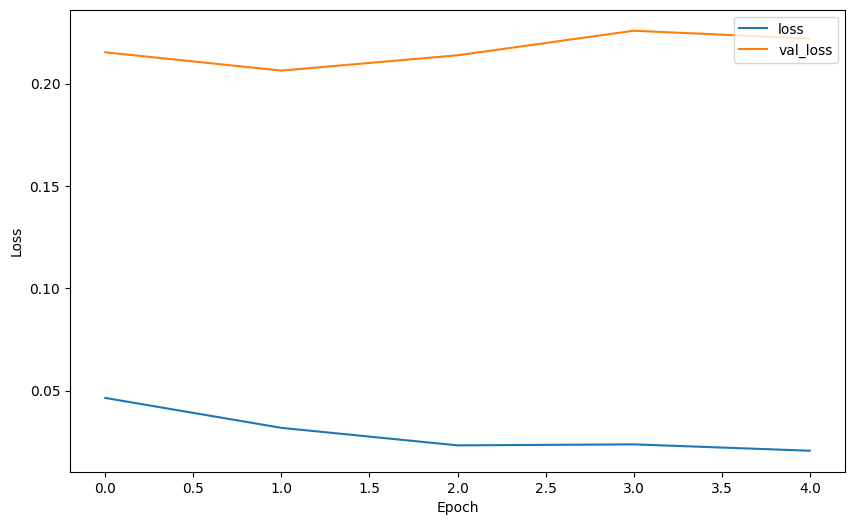

In [39]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

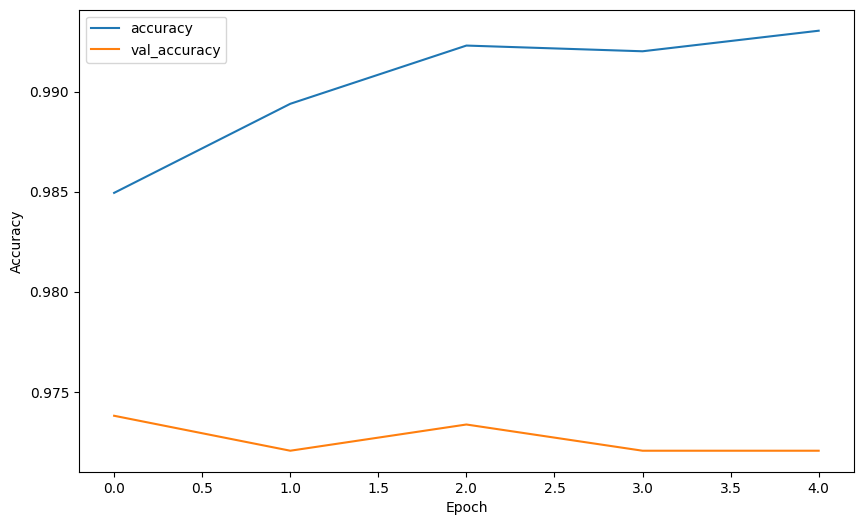

In [40]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

In [41]:
EfficientNetV2S_model.metrics_names

['loss', 'compile_metrics']

In [42]:
EfficientNetV2S_model.evaluate(test_image_gen)

36/36 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.9828 - loss: 0.1187


[0.2219431847333908, 0.9720523953437805]

In [43]:
pred_probabilities = EfficientNetV2S_model.predict(test_image_gen)

36/36 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step


In [44]:
pred_probabilities

array([[1.7727815e-06],
       [9.2398285e-09],
       [4.6788778e-06],
       ...,
       [9.9999726e-01],
       [9.9999994e-01],
       [1.0000000e+00]], dtype=float32)

In [45]:
test_image_gen.classes[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=int32)

In [46]:
predictions = pred_probabilities > 0.5

In [47]:
predictions[:50]

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False]])

In [48]:
from sklearn.metrics import classification_report,confusion_matrix

In [49]:
print(classification_report(test_image_gen.classes,predictions))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1219
           1       0.98      0.96      0.97      1071

    accuracy                           0.97      2290
   macro avg       0.97      0.97      0.97      2290
weighted avg       0.97      0.97      0.97      2290



In [50]:
confusion_matrix(test_image_gen.classes,predictions)

array([[1200,   19],
       [  45, 1026]])

From **Kaggle**: https://www.kaggle.com/code/bhuvanchennoju/hey-siri-is-it-a-or-class-f1-0-992